## 🏥 Insurance Charges Prediction using Linear Regression

### Project Overview
In this project, we predict medical insurance charges based on patient data such as age, BMI, number of children, smoking habits, and more. We follow a complete ML pipeline: data cleaning → EDA → feature selection → model building → evaluation.

---

### Step 1: Importing Libraries
We begin by importing the essential Python libraries for data manipulation, visualization, and machine learning.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Loading the Dataset
We load the insurance dataset from a CSV file into a Pandas DataFrame.

In [54]:
df = pd.read_csv("insurance.csv")

### Step 3: Initial Data Exploration
A quick look at the first few rows to understand the structure and features of the dataset.

In [55]:
df.head()


,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


We inspect data types and check for any non-null counts to get a high-level summary of the dataset.

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

### Step 4: Exploring Categorical & Discrete Columns
We check the distribution of key columns — `children`, `smoker`, and `NUmber_of_past_hospitalizations` — to understand their unique values.

In [57]:
df["children"].value_counts()

,count
children,
0.0,574
1.0,321
2.0,240
3.0,156
4.0,25
5.0,17


In [58]:
df["smoker"].value_counts()

,count
smoker,
no,1064
yes,274


In [59]:
df['NUmber_of_past_hospitalizations'].value_counts()

,count
NUmber_of_past_hospitalizations,
1.0,957
2.0,227
0.0,150
3.0,2


### Step 5: Handling Missing Values
We identify the total count of missing values per column and remove rows with null entries to ensure a clean dataset.

In [60]:
df.isnull().sum().sum()

np.int64(52)

In [61]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [62]:
df.dropna(inplace=True)

In [63]:
df.isnull().sum().sum()

np.int64(0)

### Step 6: Checking for Duplicate Rows
We verify whether the dataset contains any duplicate entries that could bias our model.

In [64]:
df.duplicated().sum()

np.int64(0)

### Step 7: Outlier Detection (Boxplots)
We visualize boxplots for all numerical (float) columns to identify potential outliers before modeling.

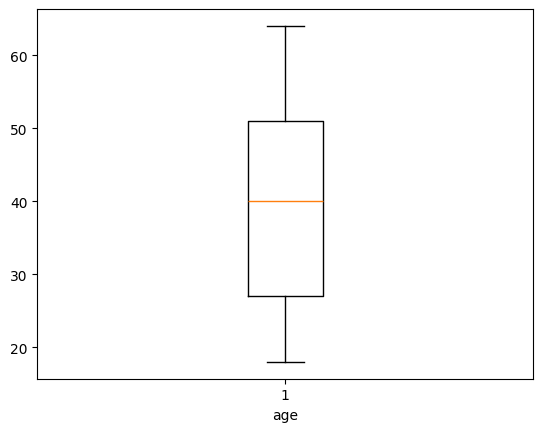

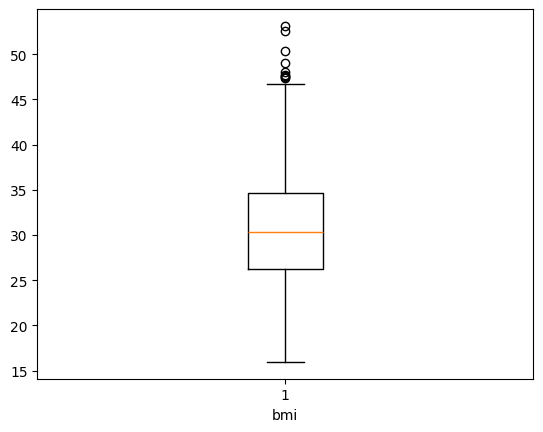

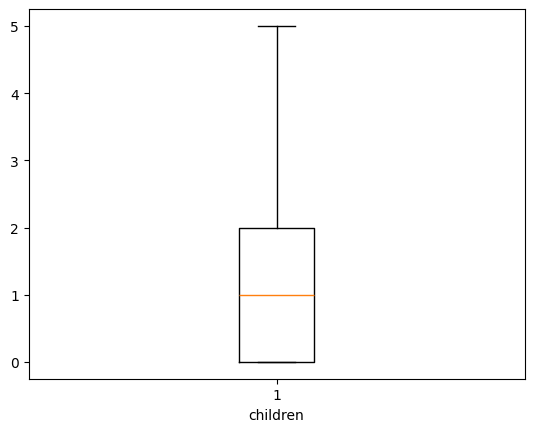

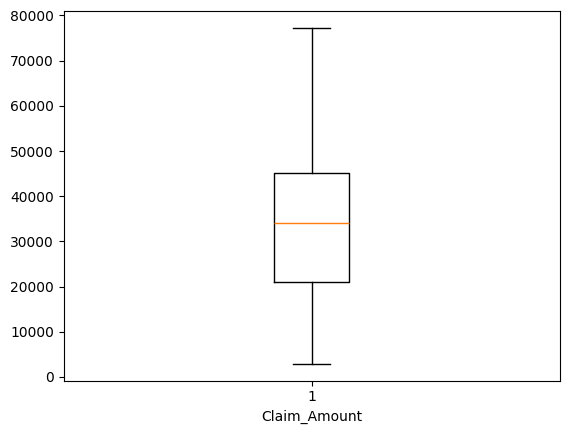

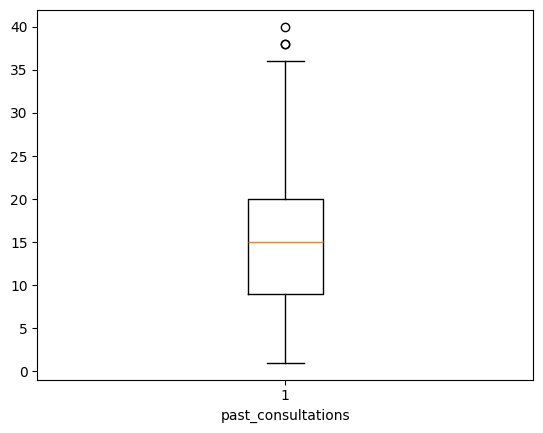

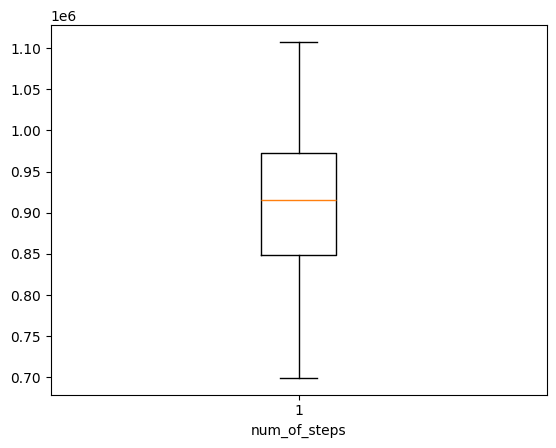

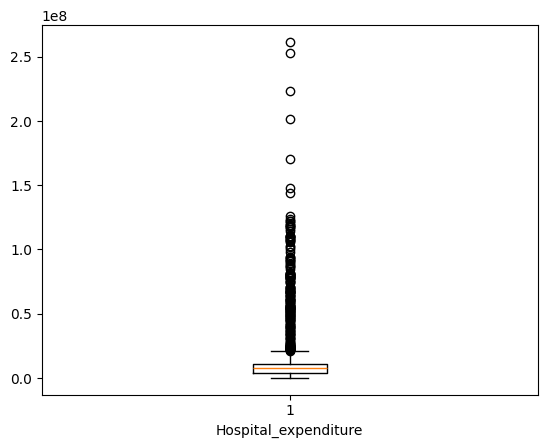

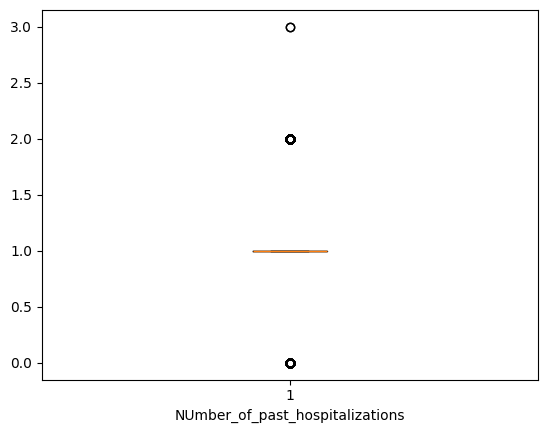

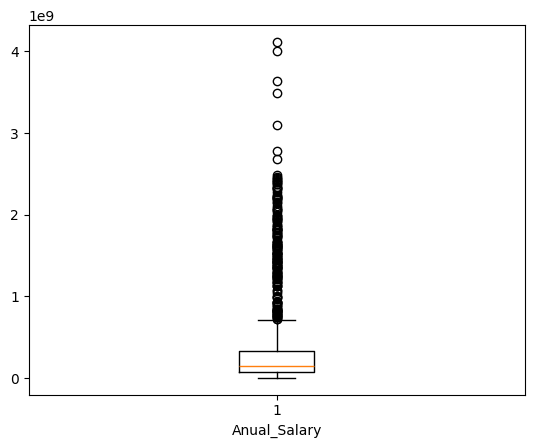

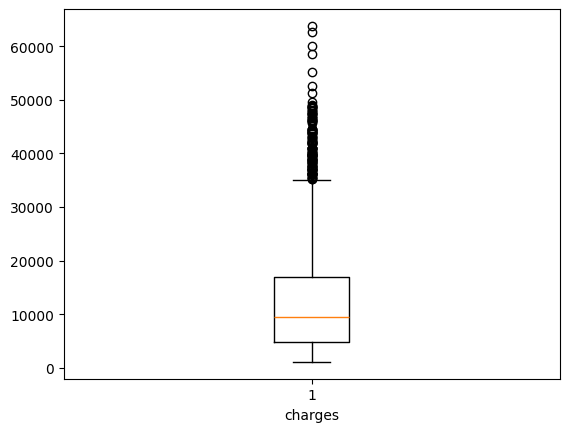

In [65]:
for ch in df.columns:
  if df[ch].dtype == "float64":
    plt.boxplot(df[ch])
    plt.xlabel(ch)
    plt.show()

### Step 8: Encoding Categorical Variables
Since machine learning models require numerical input, we use **Label Encoding** to convert all object-type (categorical) columns into numeric form.

In [66]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [67]:
for i in df.columns:
  if df[i].dtype == "object":
    df[i]=le.fit_transform(df[i])

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1287 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1287 non-null   float64
 1   sex                              1287 non-null   int64  
 2   bmi                              1287 non-null   float64
 3   children                         1287 non-null   float64
 4   smoker                           1287 non-null   int64  
 5   Claim_Amount                     1287 non-null   float64
 6   past_consultations               1287 non-null   float64
 7   num_of_steps                     1287 non-null   float64
 8   Hospital_expenditure             1287 non-null   float64
 9   NUmber_of_past_hospitalizations  1287 non-null   float64
 10  Anual_Salary                     1287 non-null   float64
 11  region                           1287 non-null   int64  
 12  charges                  

### Step 9: Correlation Analysis
A heatmap helps us visualize the correlation between all features and the target variable `charges`. Highly correlated features with each other can cause **multicollinearity**.

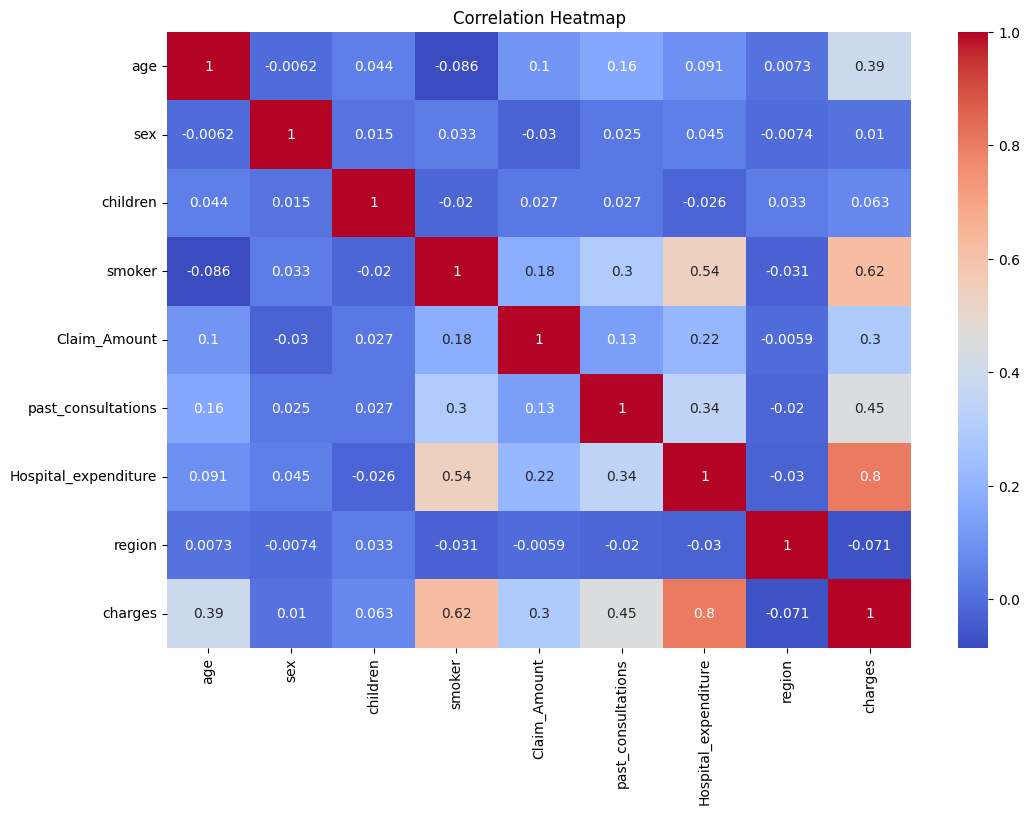

In [101]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Step 10: Multicollinearity Check using VIF (Variance Inflation Factor)
VIF measures how much a feature is explained by other features. A VIF > 5–10 indicates high multicollinearity and that feature should be removed.

We iteratively:
1. Compute VIF for all features
2. Drop the feature with the highest VIF
3. Repeat until all VIFs are acceptable

In [69]:
X = df.drop(["charges"] ,axis=1)

In [70]:
X

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,0,35.530,0.0,1,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,1
1334,31.0,0,38.095,1.0,1,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,0
1335,52.0,1,34.485,3.0,1,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,1
1336,45.0,1,30.360,0.0,1,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,2


In [71]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [72]:
vif_data=pd.DataFrame()

In [73]:
vif_data["column_name"]=X.columns

In [74]:
vif_data

,column_name
0,age
1,sex
2,bmi
3,children
4,smoker
5,Claim_Amount
6,past_consultations
7,num_of_steps
8,Hospital_expenditure
9,NUmber_of_past_hospitalizations


In [75]:
vif_data["VIF_values"]=[variance_inflation_factor(X.values , i) for i in range(len(X.columns))]

In [76]:
vif_data

,column_name,VIF_values
0,age,13.710629
1,sex,2.009831
2,bmi,30.159136
3,children,1.972347
4,smoker,4.073851
5,Claim_Amount,6.952488
6,past_consultations,8.593570
7,num_of_steps,71.160415
8,Hospital_expenditure,30.397183
9,NUmber_of_past_hospitalizations,17.904578


In [77]:
df=df.drop(["num_of_steps"],axis=1)

In [78]:
X =df.drop(['charges'], axis = 1)
vif_data = pd.DataFrame()
vif_data["Column_name"] = X.columns
vif_data['VIF Values'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(vif_data)

                        Column_name  VIF Values
0                               age   10.736430
1                               sex    1.984762
2                               bmi   14.403274
3                          children    1.955069
4                            smoker    3.553972
5                      Claim_Amount    6.464483
6                past_consultations    7.933581
7              Hospital_expenditure   30.250111
8   NUmber_of_past_hospitalizations   15.564821
9                      Anual_Salary   46.506789
10                           region    2.924170


In [79]:
df=df.drop(["Anual_Salary"],axis=1)

In [80]:
X =df.drop(['charges'], axis = 1)
vif_data = pd.DataFrame()
vif_data["Column_name"] = X.columns
vif_data['VIF Values'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(vif_data)

                       Column_name  VIF Values
0                              age   10.728714
1                              sex    1.984411
2                              bmi   13.717810
3                         children    1.937420
4                           smoker    2.899118
5                     Claim_Amount    6.463172
6               past_consultations    7.761744
7             Hospital_expenditure    2.958474
8  NUmber_of_past_hospitalizations   12.990020
9                           region    2.914537


In [81]:
df=df.drop(["bmi"],axis=1)

In [82]:
X =df.drop(['charges'], axis = 1)
vif_data = pd.DataFrame()
vif_data["Column_name"] = X.columns
vif_data['VIF Values'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(vif_data)

                       Column_name  VIF Values
0                              age    9.413509
1                              sex    1.895469
2                         children    1.929162
3                           smoker    2.788492
4                     Claim_Amount    5.842162
5               past_consultations    7.171586
6             Hospital_expenditure    2.956974
7  NUmber_of_past_hospitalizations   12.780571
8                           region    2.581048


In [83]:
df=df.drop(["NUmber_of_past_hospitalizations"],axis=1)

In [84]:
X =df.drop(['charges'], axis = 1)
vif_data = pd.DataFrame()
vif_data["Column_name"] = X.columns
vif_data['VIF Values'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(vif_data)

            Column_name  VIF Values
0                   age    6.691831
1                   sex    1.893288
2              children    1.805392
3                smoker    2.500650
4          Claim_Amount    5.588845
5    past_consultations    6.928823
6  Hospital_expenditure    2.641633
7                region    2.580397


### Step 11: Splitting Features and Target Variable
We separate the independent variables (X) from the target variable (y = `charges`), then split the data into 80% training and 20% testing sets.

In [85]:
x=df.drop(["charges"],axis=1)
y=df["charges"]

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=7)

### Step 12: Building the Linear Regression Model
We train a **Linear Regression** model on the training data. Linear Regression tries to find the best-fit straight line that minimizes the sum of squared errors.

In [88]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()



In [89]:
model.fit(x_train,y_train)

LinearRegression()

### Step 13: Making Predictions
The trained model predicts insurance charges on the unseen test data.

In [90]:
y_pred=model.predict(x_test)

In [91]:
y_pred

array([ 4461.2589086 , 15618.05847358,  3606.47593037,  9178.56906226,
       13174.98166311, 11665.68331975, 12880.5735257 , 52691.57108078,
        5877.39979655,  4437.83710579,  5456.02099189,  4780.20694118,
        3804.45197511,  3809.26791083,  8359.06158797,  4782.29366842,
        9009.94122695, 19057.63239214,  9749.21581113, 12589.30225398,
        2142.30134461,  8495.79086839,  1653.06404358,  5739.88074283,
       10243.20510486, 13785.13785613,  9958.12093369,  7274.33680068,
       26047.14031066, 20040.95684163,  8319.51216416, 27013.46151412,
         723.52186024, 11483.80199545,  8070.087313  ,  1389.71613916,
       14939.57789577, 13063.45349495, 24842.78933606,  8544.26095393,
        4302.64987134,  8306.43357478, 10030.10237334,  7783.25069684,
        4207.30015519,  7289.63317292,  3125.54737538,  5151.61150998,
        6909.24982678, 40045.63279285,  6891.83589946, 12088.33101703,
       12988.74978896,  5859.44507721, 11707.56513825, 13602.55258143,
      

### Step 14: Initial Model Evaluation (R² Score)
We evaluate the model's performance using the R² (coefficient of determination) score — higher is better, with 1.0 being perfect.

In [92]:
from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred))

0.8670775266177403


In [93]:
df.shape

(1287, 9)

### Step 15: Outlier Treatment using IQR Method
Outliers in the `charges` column can degrade model performance. We use the **Interquartile Range (IQR)** method to filter out extreme values and improve the model.

In [94]:
q1=df["charges"].quantile(0.25)
q3=df["charges"].quantile(0.75)
iqr=q3-q1
df=df[(df["charges"] >= q1 -1.5*iqr) & (df["charges"] <= q3 +1.5*iqr)]

In [95]:
df.shape

(1162, 9)

### Step 16: Re-checking Correlation After Outlier Removal
We regenerate the correlation heatmap on the cleaned data to see if relationships between features have changed.

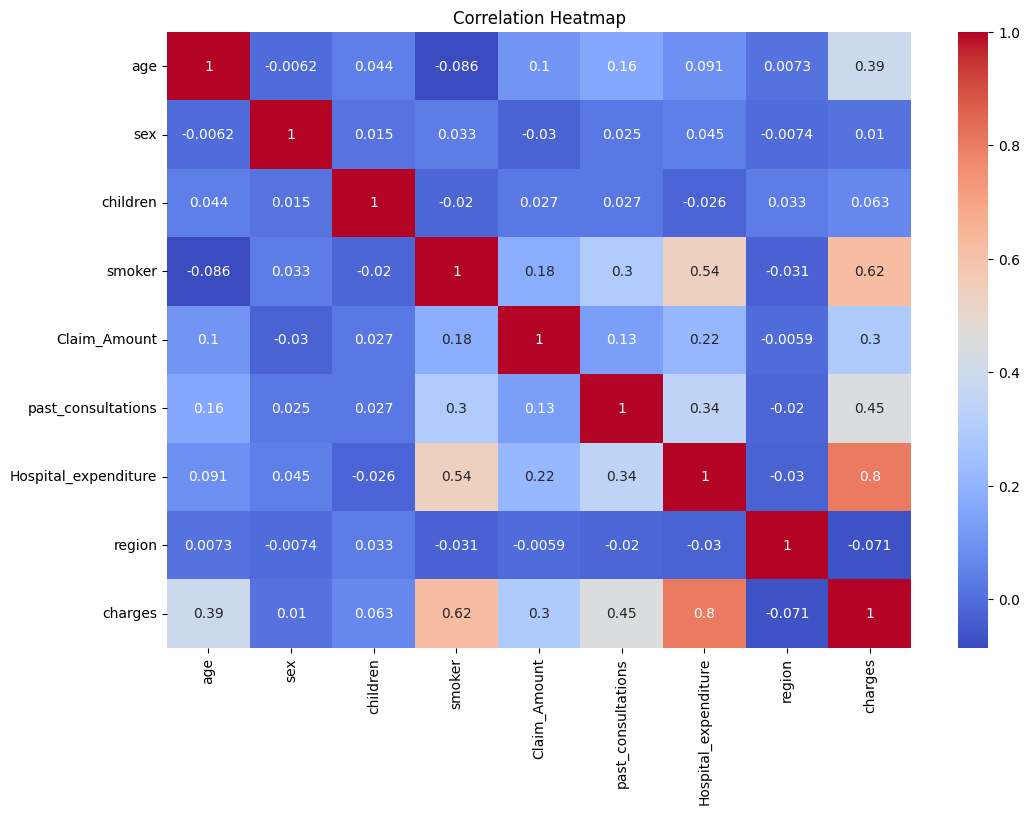

In [100]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Step 17: Visualizing Distribution of Charges
We compare the original distribution of `charges` with its log-transformed version. Log transformation often helps normalize a skewed target variable.

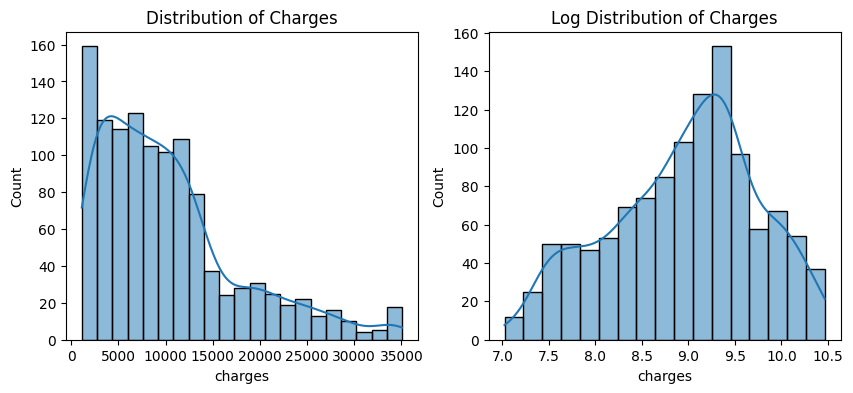

In [102]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')

plt.subplot(1,2,2)
sns.histplot(np.log(df['charges']), kde=True)
plt.title('Log Distribution of Charges')
plt.show()

### Step 18: Final Model Evaluation
We compute three key regression metrics:
- **R² Score** — how well the model explains variance in the data
- **MAE (Mean Absolute Error)** — average absolute prediction error
- **RMSE (Root Mean Squared Error)** — penalizes large errors more than MAE

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² Score  : {r2:.4f}")
print(f"MAE       : {mae:.2f}")
print(f"RMSE      : {rmse:.2f}")

R² Score  : 0.8671
MAE       : 2600.41
RMSE      : 4248.75


### Step 19: Actual vs Predicted Plot
A scatter plot comparing actual vs predicted charges. Points close to the red diagonal line indicate accurate predictions.

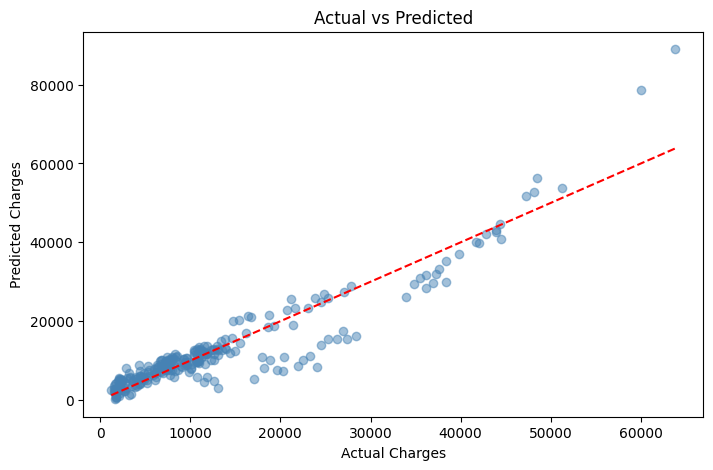

In [97]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted')
plt.show()

---

## 📌 Conclusion

In this project, we successfully built a **Linear Regression model** to predict medical insurance charges. Key highlights:

- Cleaned the data by handling missing values and removing outliers using the IQR method
- Removed multicollinear features using **VIF analysis**
- Applied **Label Encoding** for categorical variables
- Achieved a reasonable R² score after outlier treatment
- Visualized model performance using Actual vs Predicted scatter plot

**Next Steps:** Experiment with polynomial features, Ridge/Lasso regression, or tree-based models to improve accuracy.